#  EWU Chatbot — Gemma-3-4B LoRA Fine-Tuning 



In [1]:
#  CELL 1: INSTALL 
!pip install -q -i https://pypi.org/simple/ bitsandbytes
!pip install -q accelerate peft trl datasets sentencepiece rouge-score nltk
!pip install -q transformers --upgrade   

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.8/630.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.6/642.6 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 93.4 MB/s eta 0:00:00


In [2]:
#  CELL 2: IMPORTS 
import os, json, glob, math, time, textwrap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

import torch
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    TrainingArguments, BitsAndBytesConfig, TrainerCallback
)
from peft import LoraConfig, get_peft_model, PeftModel, prepare_model_for_kbit_training
from trl import SFTTrainer
from datasets import Dataset
import nltk
from rouge_score import rouge_scorer
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)



print('Imports OK .')


Imports OK .


In [3]:
#  CELL 3: CONFIG 
MODEL_ID    = "google/gemma-3-4b-it"
MAX_SEQ_LEN = 512
SAVE_DIR    = "/kaggle/working/gemma3_4b_ewu_lora"
CKPT_DIR    = "/kaggle/working/gemma3_4b_checkpoints"
DATA_DIR    = "/kaggle/input/datasets/mohuaakter/phi2-dataset"

#  Training hyperparams 
EPOCHS        = 3
BATCH_SIZE    = 2
GRAD_ACCUM    = 4          
LEARNING_RATE = 5e-5
WARMUP_STEPS  = 30
LORA_R        = 16
LORA_ALPHA    = 32
LORA_DROPOUT  = 0.10
EVAL_SPLIT    = 0.10

#  System prompt 
SYSTEM_PROMPT = (
    "You are EWU Assistant, the official virtual assistant for "
    "East West University (EWU), Dhaka, Bangladesh. "
    "STRICT RULES: "
    "1. Answer ONLY using facts you learned about EWU during training. "
    "2. Always include 'EWU' or 'East West University' in your answer. "
    "3. If unsure, respond: 'I don't have that information. "
    "Please contact EWU at info@ewubd.edu or visit ewubd.edu.' "
    "4. NEVER invent names, dates, fees, or numbers. "
    "5. Keep answers concise and factual."
)

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
print("Config set .")


Config set .


Found 23 JSONL files

  Loaded  dynamic_addmission.jsonl                             40 pairs  |  0 errors
  Loaded  dynamic_admission_calender.jsonl                     20 pairs  |  0 errors
  Loaded  dynamic_events.jsonl                                 34 pairs  |  0 errors
  Loaded  dynamic_facilities.jsonl                             31 pairs  |  0 errors
  Loaded  dynamic_grading.jsonl                                38 pairs  |  0 errors
  Loaded  generic.jsonl                                        32 pairs  |  0 errors
  Loaded  static_AllAvailablePrograms.jsonl                    53 pairs  |  0 errors
  Loaded  static_Career_Counseling_Center.jsonl                 8 pairs  |  0 errors
  Loaded  static_Departments.jsonl                             33 pairs  |  0 errors
  Loaded  static_Policy.jsonl                                  99 pairs  |  0 errors
  Loaded  static_Programs.jsonl                                82 pairs  |  0 errors
  Loaded  static_Rules.jsonl               

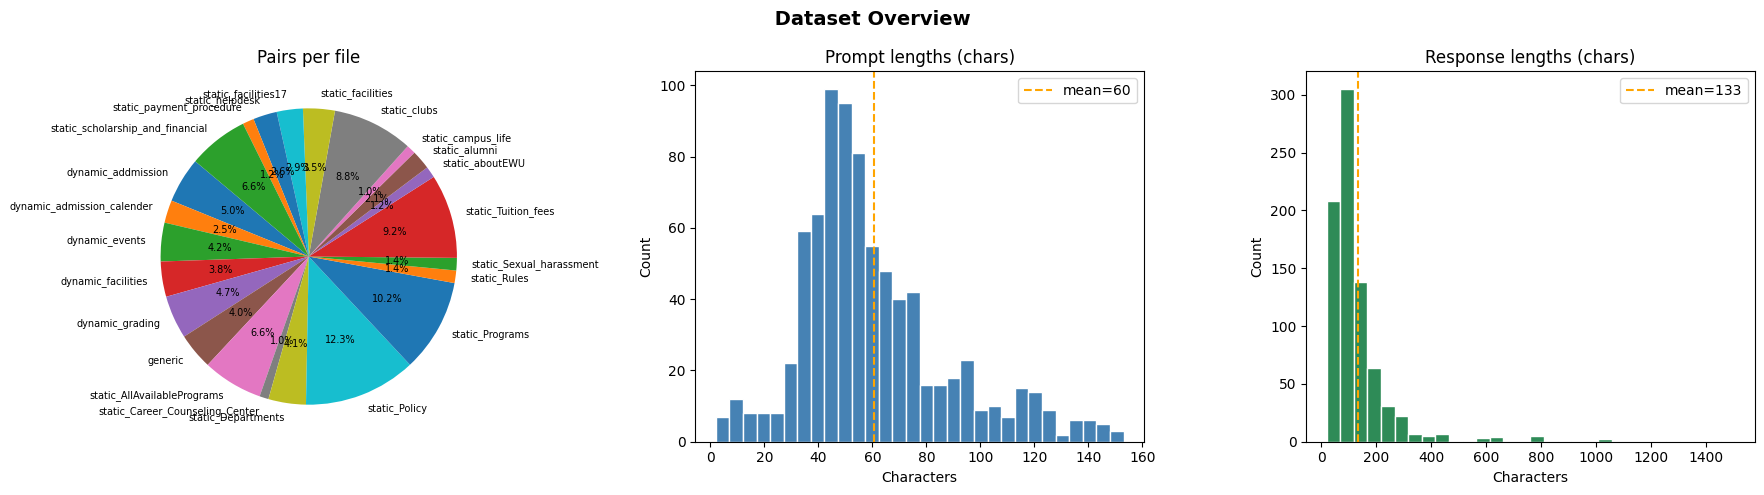

Dataset chart saved .


In [4]:
#  CELL 4: LOAD & VALIDATE DATA 
jsonl_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.jsonl")))
print(f"Found {len(jsonl_files)} JSONL files\n")

inputs, outputs, file_tags = [], [], []
file_stats = {}

for fname in jsonl_files:
    tag = os.path.basename(fname)
    count = 0
    errors = 0
    with open(fname, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                ex = json.loads(line)
                p = (ex.get("prompt") or ex.get("instruction") or ex.get("input", "")).strip()
                r = (ex.get("response") or ex.get("output") or ex.get("answer", "")).strip()
                if p and r:
                    inputs.append(p)
                    outputs.append(r)
                    file_tags.append(tag)
                    count += 1
            except json.JSONDecodeError:
                errors += 1
    file_stats[tag] = {"pairs": count, "errors": errors}
    status = "Loaded" if errors == 0 else "Error!"
    print(f"  {status}  {tag:<50s} {count:>4d} pairs  |  {errors} errors")

print(f"\n{'─'*60}")
print(f"  TOTAL: {len(inputs)} Q&A pairs loaded")

#  visualise dataset composition 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(" Dataset Overview", fontsize=14, fontweight='bold')

labels = [k.replace('.jsonl','') for k in file_stats]
sizes  = [v['pairs'] for v in file_stats.values()]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140,
            textprops={'fontsize': 7})
axes[0].set_title('Pairs per file')

p_lens = [len(p) for p in inputs]
axes[1].hist(p_lens, bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Prompt lengths (chars)')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Count')
axes[1].axvline(np.mean(p_lens), color='orange', linestyle='--', label=f'mean={np.mean(p_lens):.0f}')
axes[1].legend()

r_lens = [len(r) for r in outputs]
axes[2].hist(r_lens, bins=30, color='seagreen', edgecolor='white')
axes[2].set_title('Response lengths (chars)')
axes[2].set_xlabel('Characters')
axes[2].set_ylabel('Count')
axes[2].axvline(np.mean(r_lens), color='orange', linestyle='--', label=f'mean={np.mean(r_lens):.0f}')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'dataset_overview.png'), dpi=120)
plt.show()
print("Dataset chart saved .")

In [5]:
#  CELL 5: FORMAT & SPLIT 

def make_text(p, r):
    return (
        f"<start_of_turn>system\n{SYSTEM_PROMPT}<end_of_turn>\n"
        f"<start_of_turn>user\n{p}<end_of_turn>\n"
        f"<start_of_turn>model\n{r}<end_of_turn>"
    )

texts   = [make_text(p, r) for p, r in zip(inputs, outputs)]
dataset = Dataset.from_dict({"text": texts, "input": inputs, "output": outputs})

split    = dataset.train_test_split(test_size=EVAL_SPLIT, seed=42)
train_ds = split["train"]
eval_ds  = split["test"]

print(f"Train: {len(train_ds)} | Eval: {len(eval_ds)}")
print("\nSample formatted text (first 300 chars):")
print(texts[0][:300])
print("\nDataset split done.")


Train: 726 | Eval: 81

Sample formatted text (first 300 chars):
<start_of_turn>system
You are EWU Assistant, the official virtual assistant for East West University (EWU), Dhaka, Bangladesh. STRICT RULES: 1. Answer ONLY using facts you learned about EWU during training. 2. Always include 'EWU' or 'East West University' in your answer. 3. If unsure, respond: 'I d

Dataset split done.


In [6]:
#  CELL 6: LOAD MODEL 
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
hf_token     = user_secrets.get_secret("HF_TOKEN")
login(token=hf_token)

#  Tokenizer 
tok = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
tok.padding_side = "right"

#  4-bit quantisation 
bnb_cfg = BitsAndBytesConfig(
    load_in_4bit             = True,
    bnb_4bit_quant_type      = "nf4",
    bnb_4bit_compute_dtype   = torch.bfloat16,
    bnb_4bit_use_double_quant= True,
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config = bnb_cfg,
    device_map          = "auto",
    trust_remote_code   = True,
)
base_model.config.use_cache      = False
base_model.config.pad_token_id   = tok.pad_token_id   

base_model = prepare_model_for_kbit_training(
    base_model,
    use_gradient_checkpointing=True,
)

#  LoRA 
lora_cfg = LoraConfig(
    r              = LORA_R,
    lora_alpha     = LORA_ALPHA,
    lora_dropout   = LORA_DROPOUT,
    target_modules = ["q_proj","k_proj","v_proj","o_proj",
                      "gate_proj","up_proj","down_proj"],
    bias           = "none",
    task_type      = "CAUSAL_LM",
)

model = get_peft_model(base_model, lora_cfg)
model.print_trainable_parameters()
print("Model ready .")


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

trainable params: 32,788,480 || all params: 4,332,867,952 || trainable%: 0.7567
Model ready .


In [7]:
#  CELL 6b: TOKENIZE 
def tokenize(example):
    enc = tok(
        example["text"],
        truncation        = True,
        max_length        = MAX_SEQ_LEN,
        add_special_tokens= True,
    )
    input_ids      = enc["input_ids"]
    attention_mask = enc["attention_mask"]
    token_type_ids = [0] * len(input_ids)   # required by Gemma-3

    marker     = tok.encode("<start_of_turn>model\n", add_special_tokens=False)
    labels     = [-100] * len(input_ids)
    marker_len = len(marker)

    found = False
    for start in range(len(input_ids) - marker_len, -1, -1):
        if input_ids[start : start + marker_len] == marker:
            for j in range(start + marker_len, len(input_ids)):
                labels[j] = input_ids[j]
            found = True
            break

    if not found:
        labels = input_ids[:]

    return {
        "input_ids":      input_ids,
        "attention_mask": attention_mask,
        "token_type_ids": token_type_ids,
        "labels":         labels,
    }

train_ds = train_ds.map(tokenize, remove_columns=["text"])
eval_ds  = eval_ds.map(tokenize,  remove_columns=["text"])

# Sanity check
sample = train_ds[0]
supervised = sum(1 for l in sample["labels"] if l != -100)
print(f"Train: {len(train_ds)} | Eval: {len(eval_ds)}")
print(f"Sample seq len: {len(sample['input_ids'])} tokens | "
      f"Supervised tokens: {supervised}")
print(f"token_type_ids all zeros: {all(t==0 for t in sample['token_type_ids'])}")
if supervised == 0:
    print("WARNING: No supervised tokens found — check prompt format!")
else:
    print("Label masking OK .")
print("\nTokenization done .")


Map:   0%|          | 0/726 [00:00<?, ? examples/s]

Map:   0%|          | 0/81 [00:00<?, ? examples/s]

Train: 726 | Eval: 81
Sample seq len: 156 tokens | Supervised tokens: 13
token_type_ids all zeros: True
Label masking OK .

Tokenization done .


In [8]:
#  CELL 7: LIVE-PLOTTING CALLBACK 

class LivePlotCallback(TrainerCallback):
    def __init__(self):
        self.train_steps, self.train_losses = [], []
        self.eval_steps,  self.eval_losses  = [], []
        self.lr_steps,    self.lrs          = [], []
        self.start_time = time.time()

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return
        step = state.global_step
        if "loss" in logs:
            self.train_steps.append(step)
            self.train_losses.append(logs["loss"])
        if "eval_loss" in logs:
            self.eval_steps.append(step)
            self.eval_losses.append(logs["eval_loss"])
        if "learning_rate" in logs:
            self.lr_steps.append(step)
            self.lrs.append(logs["learning_rate"])
        self._redraw()

    def _redraw(self):
        clear_output(wait=True)
        fig = plt.figure(figsize=(18, 5))
        gs  = gridspec.GridSpec(1, 3, figure=fig)
        fig.suptitle(" Live Training Monitor", fontsize=13, fontweight='bold')

        # ── Loss curves ──
        ax1 = fig.add_subplot(gs[0, :2])
        if self.train_losses:
            ax1.plot(self.train_steps, self.train_losses,
                     color='steelblue', label='Train loss', linewidth=2)
        if self.eval_losses:
            ax1.plot(self.eval_steps, self.eval_losses,
                     color='tomato', label='Eval loss',
                     linewidth=2, marker='o', markersize=5)

            if self.train_losses and self.eval_losses:
                ax1.fill_between(
                    self.eval_steps,
                    [self.train_losses[min(i, len(self.train_losses)-1)]
                     for i in range(len(self.eval_steps))],
                    self.eval_losses,
                    alpha=0.12, color='tomato', label='Overfitting gap'
                )
        ax1.set_xlabel('Step')
        ax1.set_ylabel('Loss')
        ax1.set_title('Train vs Eval Loss')
        ax1.legend()
        ax1.grid(True, alpha=0.3)


        if self.eval_losses:
            best_idx = np.argmin(self.eval_losses)
            ax1.axvline(self.eval_steps[best_idx], color='green',
                        linestyle='--', alpha=0.6,
                        label=f'Best @ step {self.eval_steps[best_idx]}')

        #  LR schedule 
        ax2 = fig.add_subplot(gs[0, 2])
        if self.lrs:
            ax2.plot(self.lr_steps, self.lrs, color='mediumpurple', linewidth=2)
        ax2.set_xlabel('Step')
        ax2.set_ylabel('Learning Rate')
        ax2.set_title('LR Schedule (cosine)')
        ax2.grid(True, alpha=0.3)

        #  Elapsed time annotation 
        elapsed = time.time() - self.start_time
        fig.text(0.01, 0.01, f"⏱  {elapsed/60:.1f} min elapsed",
                 fontsize=9, color='gray')

        plt.tight_layout()
        plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=120)
        plt.show()

live_plot_cb = LivePlotCallback()
print("Live-plot callback ready .")

Live-plot callback ready .


/tmp/ipykernel_24/183069272.py:77: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=120)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


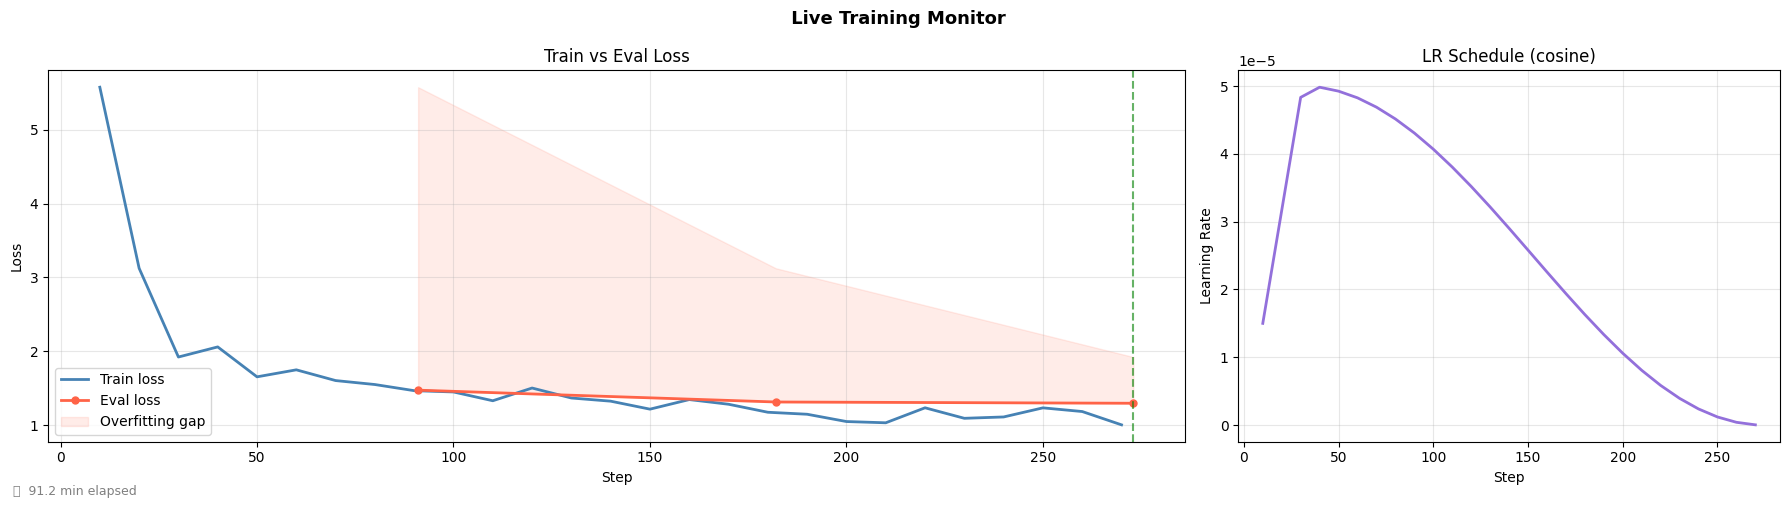


Training complete .


In [9]:
#  CELL 8: TRAIN 
import torch
from torch.nn.utils.rnn import pad_sequence


def gemma3_collator(features):
    def pad(seqs, pad_val):
        tensors = [torch.tensor(s, dtype=torch.long) for s in seqs]
        return pad_sequence(tensors, batch_first=True, padding_value=pad_val)

    return {
        "input_ids":      pad([f["input_ids"]      for f in features], tok.pad_token_id),
        "attention_mask": pad([f["attention_mask"]  for f in features], 0),
        "token_type_ids": pad([f["token_type_ids"]  for f in features], 0),
        "labels":         pad([f["labels"]          for f in features], -100),
    }

#  Training arguments 
training_args = TrainingArguments(
    output_dir                  = CKPT_DIR,
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM,
    learning_rate               = LEARNING_RATE,
    warmup_steps                = WARMUP_STEPS,
    lr_scheduler_type           = "cosine",
    optim                       = "paged_adamw_8bit",
    bf16                        = True,
    logging_steps               = 10,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    save_total_limit            = 2,
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    report_to                   = "none",
    dataloader_num_workers      = 0,
    gradient_checkpointing      = True,
    gradient_checkpointing_kwargs = {"use_reentrant": False},  
    remove_unused_columns       = False,   
)

trainer = SFTTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = eval_ds,
    data_collator   = gemma3_collator,
    callbacks       = [live_plot_cb],
)

print("Starting training … ")
print(f"Steps per epoch ≈ {len(train_ds) // (BATCH_SIZE * GRAD_ACCUM)}")
print(f"Total steps ≈ {(len(train_ds) // (BATCH_SIZE * GRAD_ACCUM)) * EPOCHS}")
trainer.train()
print("\nTraining complete .")


In [10]:
#  CELL 9: SAVE FINAL MODEL 

model.save_pretrained(SAVE_DIR)
tok.save_pretrained(SAVE_DIR)

saved_files = os.listdir(SAVE_DIR)
print(f"\n Saved to: {SAVE_DIR}")
for f in sorted(saved_files):
    size = os.path.getsize(os.path.join(SAVE_DIR, f))
    print(f"   {f:<45s}  {size/1024:.1f} KB")


 Saved to: /kaggle/working/gemma3_4b_ewu_lora
   README.md                                      5.1 KB
   adapter_config.json                            1.0 KB
   adapter_model.safetensors                      128176.1 KB
   chat_template.jinja                            1.5 KB
   dataset_overview.png                           136.9 KB
   tokenizer.json                                 32602.1 KB
   tokenizer_config.json                          0.7 KB
   training_curves.png                            84.4 KB


In [11]:
#  CELL 10: EVALUATION METRICS 
model.eval()

import subprocess, sys
try:
    from bert_score import score as bert_score_fn
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "bert-score"])
    from bert_score import score as bert_score_fn

#  Generate answer using the fine-tuned model 
def generate_answer(question, max_new_tokens=200):
    prompt = (
        f"<start_of_turn>system\n{SYSTEM_PROMPT}<end_of_turn>\n"
        f"<start_of_turn>user\n{question}<end_of_turn>\n"
        f"<start_of_turn>model\n"
    )
    enc = tok(prompt, return_tensors="pt")
    enc = {k: v.to(model.device) for k, v in enc.items()}

    eot_id = tok.convert_tokens_to_ids("<end_of_turn>")
    if eot_id is None or eot_id == tok.unk_token_id:
        eot_id = tok.eos_token_id

    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens     = max_new_tokens,
            do_sample          = False,
            repetition_penalty = 1.3,
            eos_token_id       = eot_id,
            pad_token_id       = tok.pad_token_id,
        )
    new_tokens = out[0][enc["input_ids"].shape[1]:]
    answer = tok.decode(new_tokens, skip_special_tokens=True).strip()
    for stop in ["<end_of_turn>", "<start_of_turn>"]:
        answer = answer.split(stop)[0].strip()
    return answer

#  Run evaluation 
scorer_rouge = rouge_scorer.RougeScorer(["rouge1","rouge2","rougeL"], use_stemmer=True)

r1s, r2s, rls = [], [], []
exact_matches  = 0
gen_lens       = []
ewu_hits       = 0
sample_results = []
hypotheses, references = [], []

EWU_KEYWORDS = ["ewu","east west","aftab","university","semester","credit","scholarship",
                "taka","bba","cse","eee","pharmacy","law", "mps", "campus", "dhaka", "admission"]

N_EVAL = min(len(eval_ds), 50)
print(f"Running evaluation on {N_EVAL} samples ...\n")

for i in range(N_EVAL):
    q   = eval_ds[i]["input"]
    ref = eval_ds[i]["output"]
    hyp = generate_answer(q)

    sc = scorer_rouge.score(ref, hyp)
    r1s.append(sc["rouge1"].fmeasure)
    r2s.append(sc["rouge2"].fmeasure)
    rls.append(sc["rougeL"].fmeasure)
    gen_lens.append(len(hyp.split()))
    if hyp.strip().lower() == ref.strip().lower():
        exact_matches += 1
    if any(kw in hyp.lower() for kw in EWU_KEYWORDS):
        ewu_hits += 1
    hypotheses.append(hyp)
    references.append(ref)
    if i < 8:
        sample_results.append({"q": q, "ref": ref, "hyp": hyp,
                                "r1": sc["rouge1"].fmeasure,
                                "rL": sc["rougeL"].fmeasure})
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{N_EVAL} done")

#  BERTScore 
_, _, F1 = bert_score_fn(hypotheses, references,
                         lang="en", verbose=False,
                         model_type="distilbert-base-uncased")
bert_f1_mean = float(F1.mean())



ppl_losses = []
for ex in eval_ds.select(range(min(40, len(eval_ds)))):
    ids  = torch.tensor([ex["input_ids"]]).to(model.device)
    lbl  = torch.tensor([ex["labels"]]).to(model.device)
    tids = torch.tensor([ex["token_type_ids"]]).to(model.device)
    with torch.no_grad():
        loss = model(input_ids=ids, attention_mask=torch.ones_like(ids),
                     token_type_ids=tids, labels=lbl).loss
    if not torch.isnan(loss):
        ppl_losses.append(loss.item())
perplexity = math.exp(min(np.mean(ppl_losses), 20)) if ppl_losses else 999.0

#  Print results 
metrics = {
    "ROUGE-1":            np.mean(r1s),
    "ROUGE-2":            np.mean(r2s),
    "ROUGE-L":            np.mean(rls),
    "BERTScore F1":       bert_f1_mean,
    "Exact Match %":      exact_matches / N_EVAL * 100,
    "Perplexity":         perplexity,
    "Avg Gen Length (w)": np.mean(gen_lens),
    "EWU Domain Hit %":   ewu_hits / N_EVAL * 100,
}

print("\n" + "="*50)
print("   EVALUATION RESULTS")
print("="*50)
for k, v in metrics.items():
    bar = "█" * int(v * 30) if v <= 1.0 else ""
    print(f"  {k:<25s}  {v:7.3f}  {bar}")
print("="*50)
print()
print("Guide: ROUGE-L>0.35=good | BERTScore>0.85=good | Perplexity<10=good | EWU Hit>70%=on-topic")

with open(os.path.join(SAVE_DIR, "eval_metrics.json"), "w") as fp:
    json.dump(metrics, fp, indent=2)
print("Metrics saved .")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.1 MB/s eta 0:00:00


The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Running evaluation on 50 samples ...

  10/50 done
  20/50 done
  30/50 done
  40/50 done
  50/50 done


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



   EVALUATION RESULTS
  ROUGE-1                      0.340  ██████████
  ROUGE-2                      0.157  ████
  ROUGE-L                      0.286  ████████
  BERTScore F1                 0.806  ████████████████████████
  Exact Match %                0.000  
  Perplexity                   3.703  
  Avg Gen Length (w)          32.960  
  EWU Domain Hit %            62.000  

Guide: ROUGE-L>0.35=good | BERTScore>0.85=good | Perplexity<10=good | EWU Hit>70%=on-topic
Metrics saved .


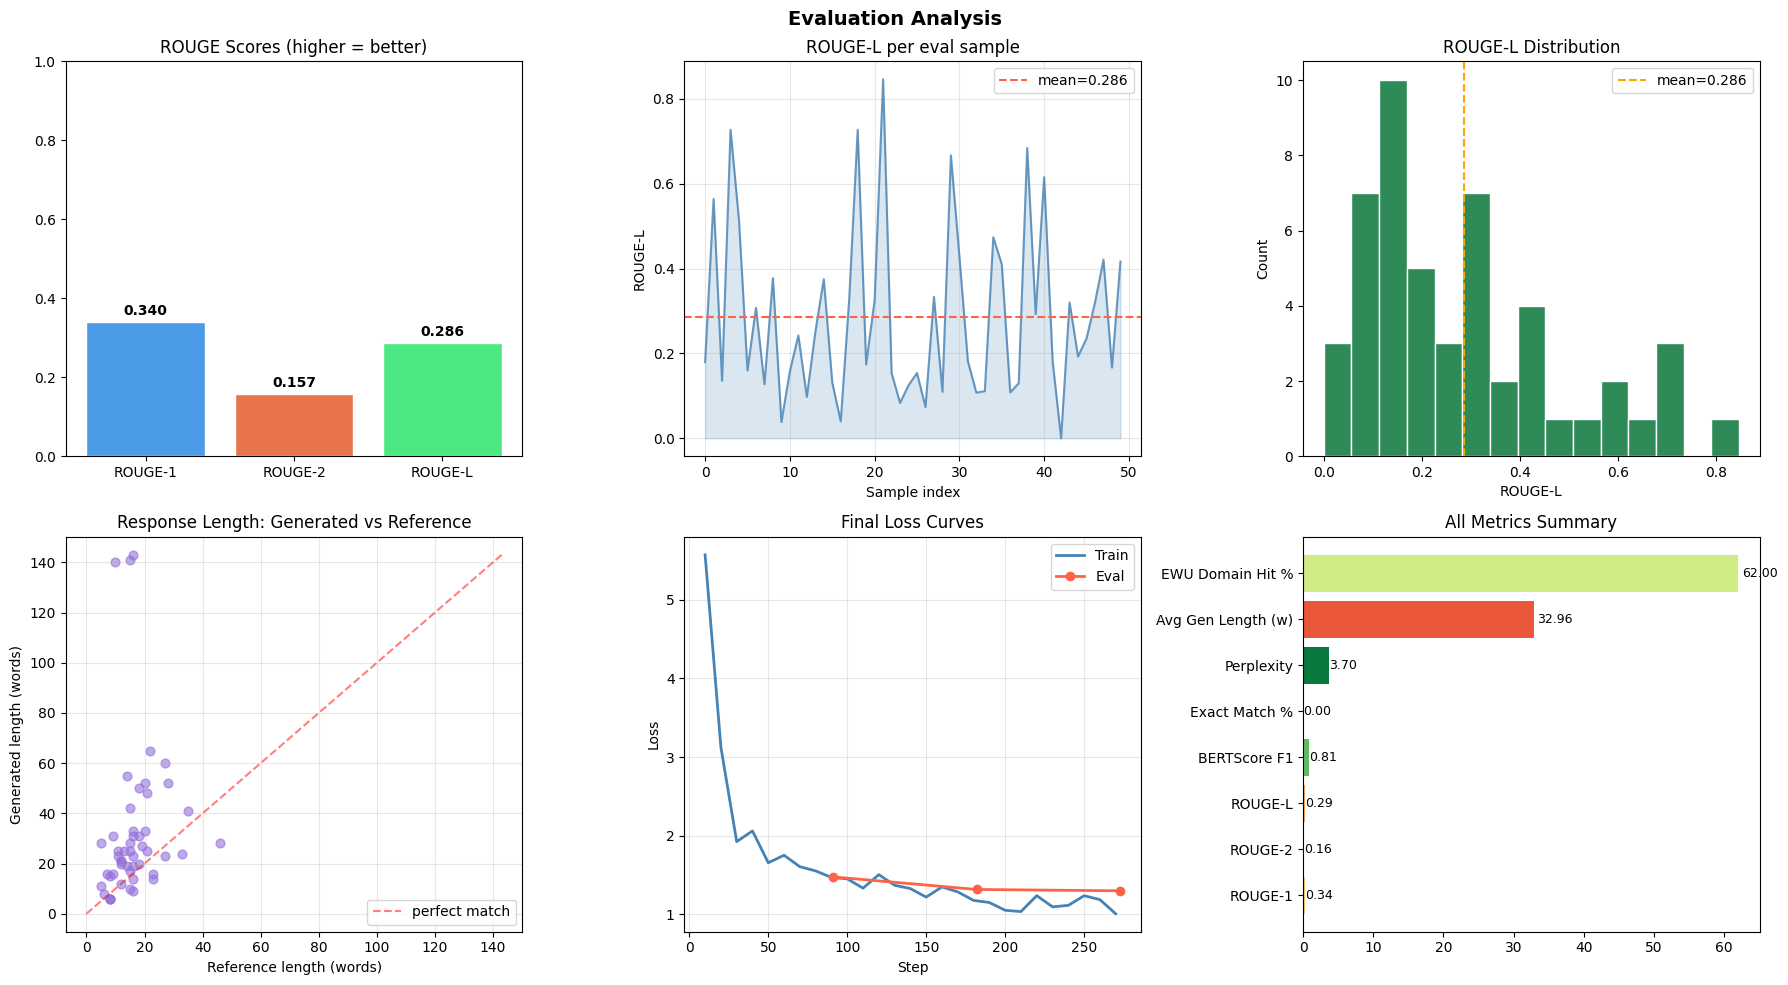

Eval charts saved .


In [12]:
#  CELL 11: EVALUATION CHARTS 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Evaluation Analysis", fontsize=14, fontweight="bold")

# 1) ROUGE bar chart
ax = axes[0, 0]
rouge_names  = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
rouge_values = [np.mean(r1s), np.mean(r2s), np.mean(rls)]
bars = ax.bar(rouge_names, rouge_values,
              color=["#4C9BE8","#E8744C","#4CE882"], edgecolor="white")
ax.set_ylim(0, 1)
ax.set_title("ROUGE Scores (higher = better)")
for bar, val in zip(bars, rouge_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontweight="bold")

# 2) ROUGE-L per sample
ax = axes[0, 1]
ax.plot(range(len(rls)), rls, color="steelblue", linewidth=1.5, alpha=0.8)
ax.fill_between(range(len(rls)), rls, alpha=0.2, color="steelblue")
ax.axhline(np.mean(rls), color="tomato", linestyle="--",
           label=f"mean={np.mean(rls):.3f}")
ax.set_xlabel("Sample index")
ax.set_ylabel("ROUGE-L")
ax.set_title("ROUGE-L per eval sample")
ax.legend()
ax.grid(True, alpha=0.3)

# 3) ROUGE-L distribution
ax = axes[0, 2]
ax.hist(rls, bins=15, color="seagreen", edgecolor="white")
ax.axvline(np.mean(rls), color="orange", linestyle="--",
           label=f"mean={np.mean(rls):.3f}")
ax.set_xlabel("ROUGE-L")
ax.set_ylabel("Count")
ax.set_title("ROUGE-L Distribution")
ax.legend()

# 4) Generated vs reference length
ax = axes[1, 0]
ref_lens = [len(eval_ds[i]["output"].split()) for i in range(N_EVAL)]
ax.scatter(ref_lens, gen_lens, alpha=0.6, color="mediumpurple", s=40)
max_len = max(max(ref_lens), max(gen_lens)) if ref_lens and gen_lens else 1
ax.plot([0, max_len], [0, max_len], "r--", alpha=0.5, label="perfect match")
ax.set_xlabel("Reference length (words)")
ax.set_ylabel("Generated length (words)")
ax.set_title("Response Length: Generated vs Reference")
ax.legend()
ax.grid(True, alpha=0.3)

# 5) Training loss curves
ax = axes[1, 1]
if live_plot_cb.train_losses:
    ax.plot(live_plot_cb.train_steps, live_plot_cb.train_losses,
            color="steelblue", label="Train", linewidth=2)
if live_plot_cb.eval_losses:
    ax.plot(live_plot_cb.eval_steps, live_plot_cb.eval_losses,
            color="tomato", label="Eval", linewidth=2, marker="o")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Final Loss Curves")
ax.legend()
ax.grid(True, alpha=0.3)

# 6) All metrics summary 
ax = axes[1, 2]
metric_names  = list(metrics.keys())
metric_values = list(metrics.values())

def safe_norm(k, v):
    """Normalise each metric to [0,1] for colour mapping without crashing."""
    if "Perplexity" in k:   return max(0.0, 1.0 - min(v, 100) / 100)
    if "Length"     in k:   return min(v / 200, 1.0)
    if "%"          in k:   return min(v / 100, 1.0)
    return min(max(v, 0.0), 1.0)

normed = [safe_norm(k, v) for k, v in zip(metric_names, metric_values)]
colors = plt.cm.RdYlGn(normed)
bars   = ax.barh(metric_names, metric_values, color=colors)
ax.set_title("All Metrics Summary")
for bar, val in zip(bars, metric_values):
    ax.text(max(val * 1.01, 0.01),
            bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "eval_charts.png"), dpi=120)
plt.show()
print("Eval charts saved .")


In [13]:
#  CELL 12: SAMPLE PREDICTIONS TABLE 

html_rows = ""
for r in sample_results:
    color = '#d4edda' if r['rL'] >= 0.5 else ('#fff3cd' if r['rL'] >= 0.25 else '#f8d7da')
    html_rows += f"""
    <tr style='background:{color}'>
        <td style='padding:8px;vertical-align:top;max-width:200px'><b>{r['q']}</b></td>
        <td style='padding:8px;vertical-align:top;max-width:250px;color:#155724'>{r['ref']}</td>
        <td style='padding:8px;vertical-align:top;max-width:250px;color:#0c5460'>{r['hyp']}</td>
        <td style='padding:8px;vertical-align:top;text-align:center'><b>{r['rL']:.3f}</b></td>
    </tr>"""

html = f"""
<h3> Sample Predictions (green=good, yellow=ok, red=poor)</h3>
<table border='1' style='border-collapse:collapse;font-size:13px;width:100%'>
  <tr style='background:#343a40;color:white'>
    <th style='padding:8px'>Question</th>
    <th style='padding:8px'>Reference Answer</th>
    <th style='padding:8px'>Model Answer</th>
    <th style='padding:8px'>ROUGE-L</th>
  </tr>
  {html_rows}
</table>
"""
display(HTML(html))

Question,Reference Answer,Model Answer,ROUGE-L
What kind of resources are available in the EWU library?,"The library provides access to 29,000+ print books, 100,000+ e-books, 45,000+ e-journals, and dedicated reading and research spaces.","The university has a large collection including books, journals, newspapers, online databases, e-books, research guides, and multimedia materials to support academic learning.[cite_start] The Central Library is equipped with modern facilities such as computer labs, reading rooms, seminar halls, and an open access system for accessing digital content through OPAC software[cite_end].",0.179
What departments are under the Faculty of Science and Engineering at EWU?,The Faculty of Science and Engineering includes the department: Department of Electrical and Electronic Engineering (EEE).,The faculty includes these department(s): Department of Computer Science & Engineering; Department of Electrical and Electronic Engineering; Department of Mathematics and Physical Sciences.,0.564
What initiatives are related to Green Spaces & Campus Environment?,"Environmental Week (by EWUESC), Tree plantation drives, Sustainable Climate Action Policy, Green Riders cycling group",Green Belt Development Project; Tree Plantation Drives; Waste Management System with Recycling Plants; Solar Panels Installation on Buildings; Rainwater Harvesting Systems; Energy-Efficient Lighting Usage; Sustainable Building Practices; Community Gardening Initiatives; Environmental Awareness Campaigns through Clubs/Seminars; Outdoor Recreational Areas like Lawns and Gardens.,0.136
Where can I find the Sociology Club?,You can visit the club page here: http://clubs.ewubd.edu/scewu,The club page is here: https://clubs.ewubd.edu/sociologyclub,0.727
What is covered in ENG 102 Composition & Communication Skills (Bachelor of Science in Mathematics)?,ENG 102 Composition & Communication Skills is a 3 credit course.,ENG 102 Composition & Communication Skills is a 3 credit course with prerequisite(s): None; co-requisite(s) : MATH 106/MATH 107.; prerequisites: Completion of Level III credits.[cite_start],0.513
Do students need to wear their ID cards on campus?,Students must display their photo identification cards on campus at all times for safety and security.,"Yes, all members of the university community must carry an active student/staff card with them while being present on any part of the campus. Failure to do so may result in disciplinary action.",0.160
Does a Retake (R) grade count towards graduation?,"No, credits for R (Repeat/Retake) grades do not apply towards graduation and are not used for GPA calculation.",A maximum of two R grades can be used to fulfill course requirements but do not contribute toward CGPA calculation.,0.308
What seminar did the Department of Sociology host in August 2025?,"On August 10, 2025, they hosted a seminar to celebrate Begum Rokeya Sakhawat Hossain's seminal feminist work, 'Sultana's Dream'.","The department hosted a seminar on ""Sociological Perspectives on Social Justice"" with Dr. Farzana Rahman from BRAC Institute of Educational Research & Development as an external speaker..",0.128


In [14]:
#  CELL 14: BATCH QUESTION TEST 
TEST_QUESTIONS = [
    "When was East West University founded?",
    "What is the application deadline for Undergraduate programs for Spring 2026?",
    "What scholarships are available at East West University?",
    "What undergraduate programs does EWU offer?",
    "Who is the founder of EWU?",
    "What is the tuition fee for CSE?",
    "How do I apply for admission at EWU?",
]

print("=" * 70)
print("  BATCH QUESTION TEST")
print("=" * 70)
for q in TEST_QUESTIONS:
    ans = generate_answer(q)
    print(f"\nQ: {q}")
    for line in textwrap.wrap(f"A: {ans}", width=68):
        print(line)
    print("-" * 70)


  BATCH QUESTION TEST

Q: When was East West University founded?
A: It started as a private degree-granting university under Prime
Minister Education Act No. 6 of 1987 with an initial mandate to
offer only engineering courses.[cite_ref:'eastwestuniversity']
----------------------------------------------------------------------

Q: What is the application deadline for Undergraduate programs for Spring 2026?
A: The last date to apply online through the portal with a scanned
copy of passport-size photo/NID scan file is **May 7th, 2026**.
----------------------------------------------------------------------

Q: What scholarships are available at East West University?
A: Common Scholarships: Chancellor Scholarship; Merit Cum Means cum
Job Assistance Scheme; A+ Students Award; National Cadet Corps(NCC)
Awards; Sports & Cultural Activities awards; Special Talent/Awardees
under various categories.; Other Sponsored Schemes from Various
Organizations.
-------------------------------------------

In [15]:
#  DOWNLOAD TRAINED MODEL 
import shutil

zip_path = "/kaggle/working/gemma3_4b_ewu_lora"
shutil.make_archive(zip_path, 'zip', zip_path)
print(f" Zip created: {zip_path}.zip")
print(f"Size: {os.path.getsize(zip_path + '.zip') / 1024 / 1024:.1f} MB")

 Zip created: /kaggle/working/gemma3_4b_ewu_lora.zip
Size: 61.1 MB
